# 07-1. Latent Space 시각화 — CVAE (PyTorch)

CVAE(β=1.5) 잠재 공간을 07 VAE 시각화와 동일한 방식으로 분석해 클러스터 분리가 개선됐는지 비교합니다.

| 항목 | VAE (07) | CVAE (07-1) |
|------|----------|-------------|
| 인코더 입력 | 이미지 | 이미지 + 레이블 |
| 레이블 학습 | 없음 | action 10 클래스 |
| 기대 효과 | 클러스터 미분리 | 액션별 분리 개선 |

## 1. 환경 설정

In [1]:
import os, json, random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# fix working directory
_root = Path(os.path.abspath(''))
for _p in [_root] + list(_root.parents):
    if (_p / 'dataset' / 'processed').exists():
        os.chdir(_p); break
print(f'CWD: {Path.cwd()}')

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

CWD: /Users/gomuseo/Desktop/Python/vae_test
Device: mps


## 2. 모델 로드 (CVAE PyTorch β=1.5)

In [2]:
CKPT_DIR = Path('checkpoints_cvae_pt')

with open(CKPT_DIR / 'config.json') as f:
    CFG = json.load(f)

LATENT_DIM  = CFG['latent_dim']
BASE_CH     = CFG['base_channels']
CHANNELS    = CFG['channels']
NUM_CLASSES = CFG['num_classes']

ACTIONS     = ['walk', 'idle', 'run', 'slash', 'shoot', 'thrust', 'jump', 'sit', 'spellcast']
LABEL_NAMES = ACTIONS + ['other']

print(f'CFG: latent_dim={LATENT_DIM}, num_classes={NUM_CLASSES}, beta={CFG["beta"]}')


class CVAEEncoder(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        layers, in_ch, ch = [], channels, base_ch
        for _ in range(4):
            layers += [nn.Conv2d(in_ch, ch, 4, stride=2, padding=1),
                       nn.BatchNorm2d(ch, momentum=0.1),
                       nn.LeakyReLU(0.2)]
            in_ch = ch; ch *= 2
        self.conv  = nn.Sequential(*layers)
        flat_dim   = (base_ch * 8) * 4 * 4
        self.fc_mu = nn.Linear(flat_dim + num_classes, latent_dim)
        self.fc_lv = nn.Linear(flat_dim + num_classes, latent_dim)

    def forward(self, x, c):
        h = self.conv(x).flatten(1)
        h = torch.cat([h, c], dim=-1)
        return self.fc_mu(h), self.fc_lv(h)


class CVAEDecoder(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        self.start_ch = base_ch * 8
        self.fc       = nn.Linear(latent_dim + num_classes, self.start_ch * 4 * 4)
        layers, in_ch = [], self.start_ch
        for i, out_ch in enumerate([base_ch*4, base_ch*2, base_ch, channels]):
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1))
            if i < 3:
                layers += [nn.BatchNorm2d(out_ch, momentum=0.1), nn.ReLU()]
            else:
                layers.append(nn.Sigmoid())
            in_ch = out_ch
        self.deconv = nn.Sequential(*layers)

    def forward(self, z, c):
        h = self.fc(torch.cat([z, c], dim=-1))
        return self.deconv(h.view(-1, self.start_ch, 4, 4))


class CVAE(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        self.encoder = CVAEEncoder(num_classes, base_ch, latent_dim, channels)
        self.decoder = CVAEDecoder(num_classes, base_ch, latent_dim, channels)

    def forward(self, x, c):
        mu, lv = self.encoder(x, c)
        z      = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return self.decoder(z, c), mu, lv


model = CVAE(NUM_CLASSES, BASE_CH, LATENT_DIM, CHANNELS).to(DEVICE)
model.load_state_dict(torch.load(CKPT_DIR / 'best.pt', map_location=DEVICE))
model.eval()
print('CVAE model loaded.')

CFG: latent_dim=128, num_classes=10, beta=1.5
CVAE model loaded.


## 3. 잠재 벡터 수집

CVAE 인코더는 이미지와 레이블을 함께 입력받습니다.

In [3]:
BODY_DIR  = Path('dataset/processed/body')
all_paths = sorted(BODY_DIR.glob('*.png'))

N_SAMPLES = 1000

def get_label(path):
    name = Path(path).name
    for i, kw in enumerate(ACTIONS):
        if kw in name:
            return i
    return len(ACTIONS)

random.seed(42)
sample_paths  = random.sample(list(all_paths), min(N_SAMPLES, len(all_paths)))
sample_labels = [get_label(p) for p in sample_paths]

to_tensor = transforms.ToTensor()

@torch.no_grad()
def encode_paths(paths, labels, batch_size=128):
    mu_list = []
    for i in range(0, len(paths), batch_size):
        batch_p = paths[i:i+batch_size]
        batch_l = labels[i:i+batch_size]
        imgs = torch.stack([
            to_tensor(Image.open(p).convert('RGBA')) for p in batch_p
        ]).to(DEVICE)
        c = F.one_hot(torch.tensor(batch_l), NUM_CLASSES).float().to(DEVICE)
        mu, _ = model.encoder(imgs, c)
        mu_list.append(mu.cpu().numpy())
    return np.concatenate(mu_list)

print(f'Encoding... ({len(sample_paths):,} images)')
Z = encode_paths(sample_paths, sample_labels)
print(f'Latent vector shape: {Z.shape}')

dist = Counter(LABEL_NAMES[l] for l in sample_labels)
print('Action distribution:', dict(sorted(dist.items(), key=lambda x: -x[1])))

Encoding... (1,000 images)


Latent vector shape: (1000, 128)
Action distribution: {'slash': 217, 'walk': 183, 'shoot': 104, 'jump': 92, 'thrust': 76, 'sit': 70, 'run': 70, 'other': 66, 'spellcast': 62, 'idle': 60}


## 4. 레이블 준비

In [4]:
CHAR_LABELS_MAP = {
    'male': 'male', 'female': 'female', 'teen': 'teen',
    'child': 'child', 'pregnant': 'pregnant', 'muscular': 'muscular',
}
ACTION_LABELS_MAP = {kw: kw for kw in ACTIONS}
ACTION_LABELS_MAP['other'] = 'other'

def assign_labels(paths, label_map):
    labels = []
    for p in paths:
        name = Path(p).name
        matched = 'other'
        for label, kw in label_map.items():
            if kw in name:
                matched = label; break
        labels.append(matched)
    return labels

char_labels   = assign_labels(sample_paths, CHAR_LABELS_MAP)
action_labels = [LABEL_NAMES[l] for l in sample_labels]  # 인코딩에 사용된 레이블과 동일

print('Character distribution:', dict(Counter(char_labels).most_common()))
print('Action distribution:   ', dict(Counter(action_labels).most_common()))

Character distribution: {'male': 402, 'teen': 201, 'pregnant': 167, 'muscular': 140, 'child': 90}
Action distribution:    {'slash': 217, 'walk': 183, 'shoot': 104, 'jump': 92, 'thrust': 76, 'sit': 70, 'run': 70, 'other': 66, 'spellcast': 62, 'idle': 60}


## 5. PCA 시각화

PCA explained variance: PC1=10.64%  PC2=9.96%


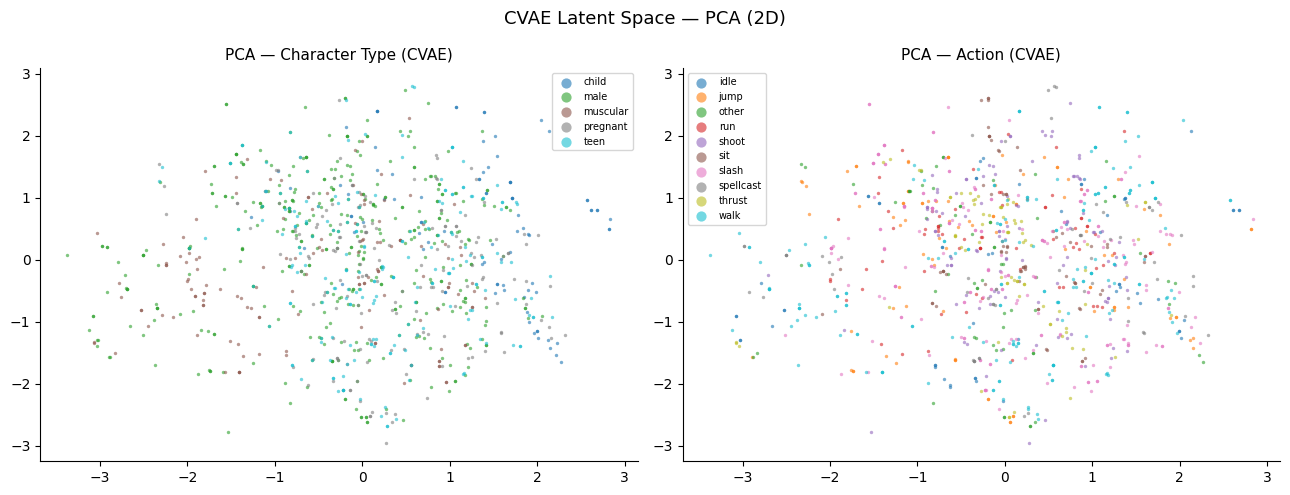

In [5]:
pca   = PCA(n_components=2, random_state=42)
Z_pca = pca.fit_transform(Z)
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}  PC2={pca.explained_variance_ratio_[1]:.2%}')


def scatter_plot(Z_2d, labels, title, ax, cmap='tab10'):
    unique = sorted(set(labels))
    colors = plt.colormaps.get_cmap(cmap).resampled(len(unique))
    for i, lbl in enumerate(unique):
        mask = np.array(labels) == lbl
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                   c=[colors(i)], label=lbl, s=6, alpha=0.6, linewidths=0)
    ax.set_title(title, fontsize=11)
    ax.legend(markerscale=3, fontsize=7, loc='best')
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter_plot(Z_pca, char_labels,   'PCA — Character Type (CVAE)', axes[0])
scatter_plot(Z_pca, action_labels, 'PCA — Action (CVAE)',         axes[1])
plt.suptitle('CVAE Latent Space — PCA (2D)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. t-SNE 시각화

Running t-SNE...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.001s...
[t-SNE] Computed neighbors for 1000 samples in 0.125s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 1.702372


[t-SNE] KL divergence after 50 iterations with early exaggeration: 66.861450


[t-SNE] KL divergence after 1000 iterations: 0.914843
Done.


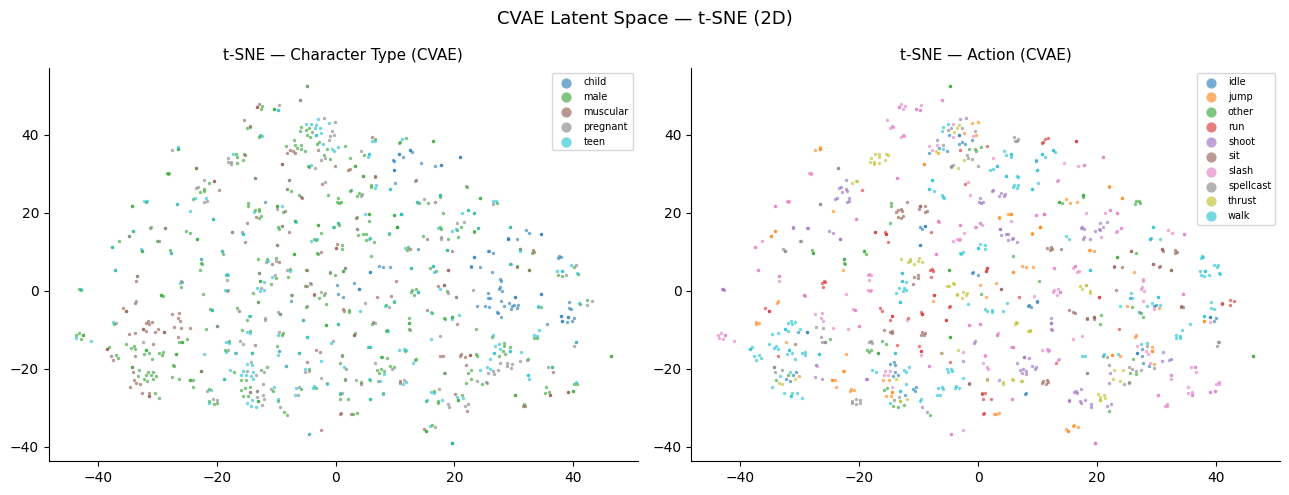

In [6]:
Z_pca50 = PCA(n_components=min(50, Z.shape[1]), random_state=42).fit_transform(Z)

print('Running t-SNE...')
tsne   = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42, verbose=1)
Z_tsne = tsne.fit_transform(Z_pca50)
print('Done.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter_plot(Z_tsne, char_labels,   't-SNE — Character Type (CVAE)', axes[0])
scatter_plot(Z_tsne, action_labels, 't-SNE — Action (CVAE)',         axes[1])
plt.suptitle('CVAE Latent Space — t-SNE (2D)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. VAE vs CVAE — idle / walk / run 분포 비교

07 노트북과 동일한 기준으로 비교합니다.

Group std comparison (CVAE vs VAE):
     group      n    CVAE std    VAE std (07)
      idle     60      0.1179          0.1292
      walk    183      0.1263          0.1446
       run     70      0.1578          0.1627


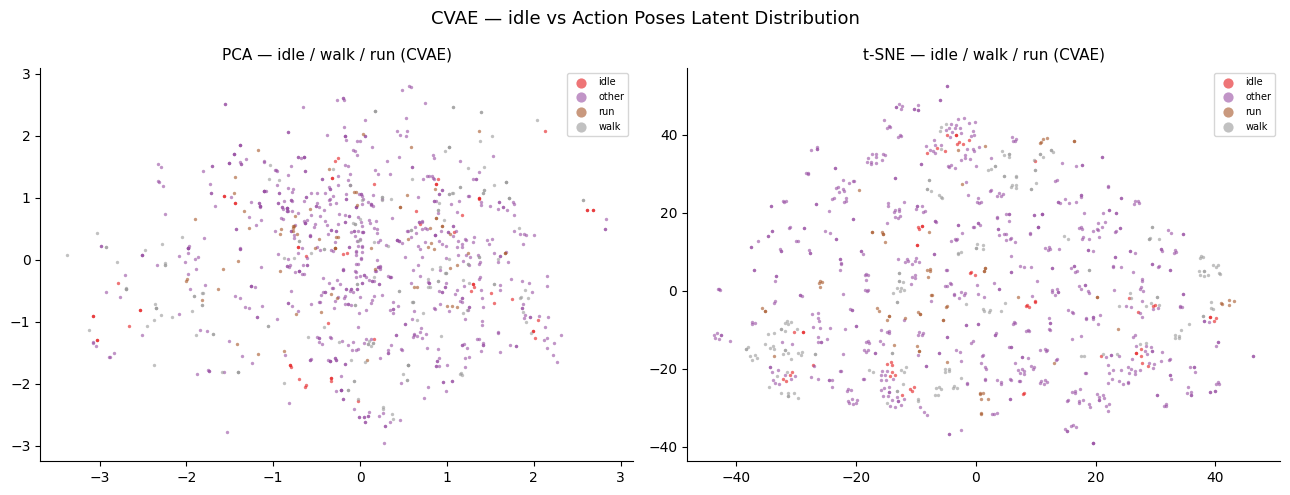

In [7]:
focus_labels = ['idle' if l == 'idle' else 'walk' if l == 'walk' else 'run' if l == 'run' else 'other'
                for l in action_labels]

print('Group std comparison (CVAE vs VAE):')
print(f'{"group":>10}  {"n":>5}  {"CVAE std":>10}  {"VAE std (07)":>14}')
vae_std = {'idle': 0.1292, 'walk': 0.1446, 'run': 0.1627}
for lbl in ['idle', 'walk', 'run']:
    mask = np.array(action_labels) == lbl
    if mask.sum() == 0: continue
    std = Z[mask].std(axis=0).mean()
    print(f'{lbl:>10}  {mask.sum():>5}  {std:>10.4f}  {vae_std[lbl]:>14.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter_plot(Z_pca,  focus_labels, 'PCA — idle / walk / run (CVAE)',   axes[0], cmap='Set1')
scatter_plot(Z_tsne, focus_labels, 't-SNE — idle / walk / run (CVAE)', axes[1], cmap='Set1')
plt.suptitle('CVAE — idle vs Action Poses Latent Distribution', fontsize=13)
plt.tight_layout()
plt.show()

## 8. UMAP 시각화 (선택)

In [8]:
# requires umap-learn: pip install umap-learn
try:
    import umap
    print('Running UMAP...')
    reducer = umap.UMAP(n_components=2, random_state=42)
    Z_umap  = reducer.fit_transform(Z)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    scatter_plot(Z_umap, char_labels,   'UMAP — Character Type (CVAE)', axes[0])
    scatter_plot(Z_umap, action_labels, 'UMAP — Action (CVAE)',         axes[1])
    plt.suptitle('CVAE Latent Space — UMAP (2D)', fontsize=13)
    plt.tight_layout()
    plt.show()
except ImportError:
    print('umap-learn not installed — run: pip install umap-learn')

umap-learn not installed — run: pip install umap-learn


## 9. 잠재 벡터 통계 요약

In [9]:
print(f"{'group':>12}  {'n':>5}  {'mu mean':>10}  {'mu std':>10}")
print('-' * 45)
for lbl in LABEL_NAMES:
    mask = np.array(action_labels) == lbl
    if mask.sum() == 0: continue
    g = Z[mask]
    print(f'{lbl:>12}  {mask.sum():>5}  {g.mean():>10.4f}  {g.std():>10.4f}')

print(f'\nAll  mean={Z.mean():.4f}  std={Z.std():.4f}  (ideal: mean=0, std=1)')
print(f'\n[VAE ref]  mean≈-0.004  std≈0.360')

       group      n     mu mean      mu std
---------------------------------------------
        walk    183     -0.0010      0.3018
        idle     60      0.0026      0.2961
         run     70     -0.0017      0.3101
       slash    217     -0.0015      0.3441
       shoot    104     -0.0023      0.3152
      thrust     76     -0.0020      0.2894
        jump     92     -0.0037      0.3348
         sit     70      0.0082      0.3025
   spellcast     62     -0.0087      0.3072
       other     66     -0.0011      0.3568

All  mean=-0.0012  std=0.3195  (ideal: mean=0, std=1)

[VAE ref]  mean≈-0.004  std≈0.360
